# Pillbox Analysis

This notebook demonstrates a complete rectangular waveguide analysis workflow:

1. Geometry creation
2. Frequency-domain analysis
3. Model order reduction
4. Comparison with analytical solution

In [1]:
from utils.visualization import *
from geometry.importers import STEPImporter, TESLACavity, GMSHImporter
from solvers.frequency_domain import FrequencyDomainSolver
from rom.reduction import ModelOrderReduction
from analytical.circular_waveguide import CWGAnalytical
from ngsolve.webgui import Draw # must import Draw, otherwise may run into problems showing mesh
from utils.visualization import (
    plot_z_comparison, 
    plot_s_comparison, 
    plot_all_parameters,
    plot_eigenfrequencies,
    ParameterPlotter,
    EigenfrequencyPlotter
)
%matplotlib inline
plt.rcParams['figure.dpi'] = 100

## 1. Define Geometry

Create a rectangular waveguide with specified dimensions and mesh parameters.

In [2]:
# 1. Load and prepare geometry
geo = STEPImporter(r"./pillbox.step", auto_build=False)
geo.add_splitting_plane_at_x(0.0)
geo.split()

geo.show_split_preview()
geo.build()
geo.name_solids(port_axis='x')

geo.generate_mesh(maxh=0.1) # after naming solids, must generate mesh but avoid rebuilding

Displayed 2 solids with distinct colors
Displayed 1 splitting plane(s)


In [3]:
geo.show('mesh')
geo.print_info()

WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.25…


STEP Geometry Information
File: ./pillbox.step
Unit: mm
Number of solids: 2
Is split: True
Number of splitting planes: 1
Plane positions (z): [-0.36000012]

Bounding Box:
  Min: (-0.7022, -0.3022, -0.3000)
  Max: (0.7022, 0.3022, 0.3000)
  Size: (1.4044, 0.6044, 0.6000)

NGSolve geometry built: True
Mesh generated: True



Structure Topology
Type: Compound structure
Domains (2): ['cell_1', 'cell_2']
Total Ports (3): ['port1', 'port2', 'port3']
External Ports (2): ['port1', 'port3']
Internal Ports (1): ['port2']

Domain-Port Mapping:
  cell_1: ['port1 (external, input)', 'port2 (internal)']
  cell_2: ['port2 (internal)', 'port3 (external, output)']

Assembling Matrices...

Solving port eigenmodes...

	Calculating Port Eigenmodes...
	  Mode source: analytic
	  Polarization angle: 0.0°
	  Requested modes per port: 3
	------------------------------------------------------------
	  port1: circular (fit error: 0.0000)
	    R=0.100005
	  port2: circular (fit error: 0.0000)
	    R=0.100005
	  port3: circular (fit error: 0.0000)
	    R=0.100005
	  Precomputing boundary mass matrices (once per port)...
	    Done for 3 port(s)
	port1 mode 0: TE_11 (cos), kc=18.4110, σ=+1
	port1 mode 1: TE_11 (sin), kc=18.4110, σ=+1
	port1 mode 2: TM_01, kc=24.0471, σ=+1
	port2 mode 0: TE_11 (cos), kc=18.4110, σ=+1
	port2 mode 1: T

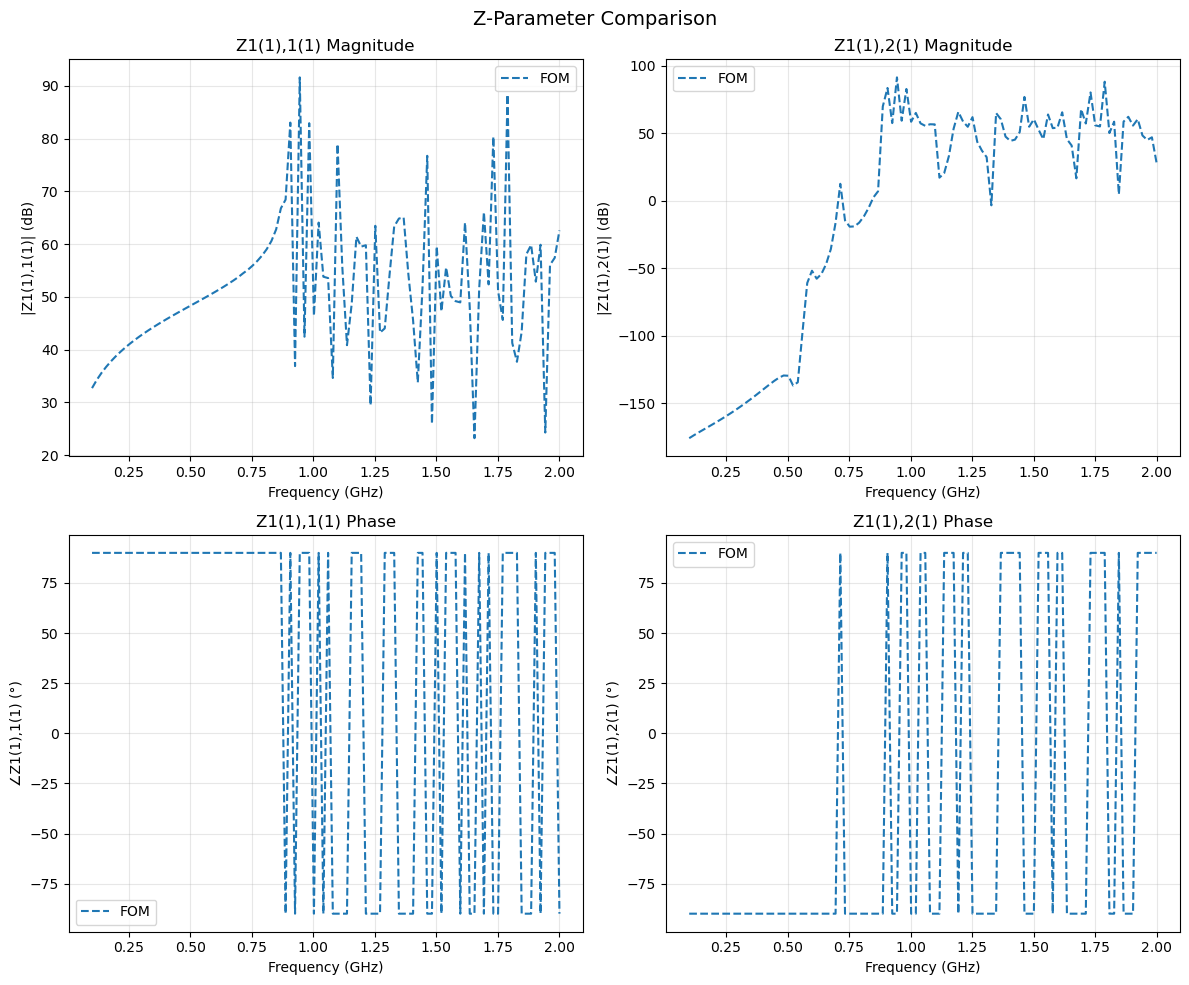

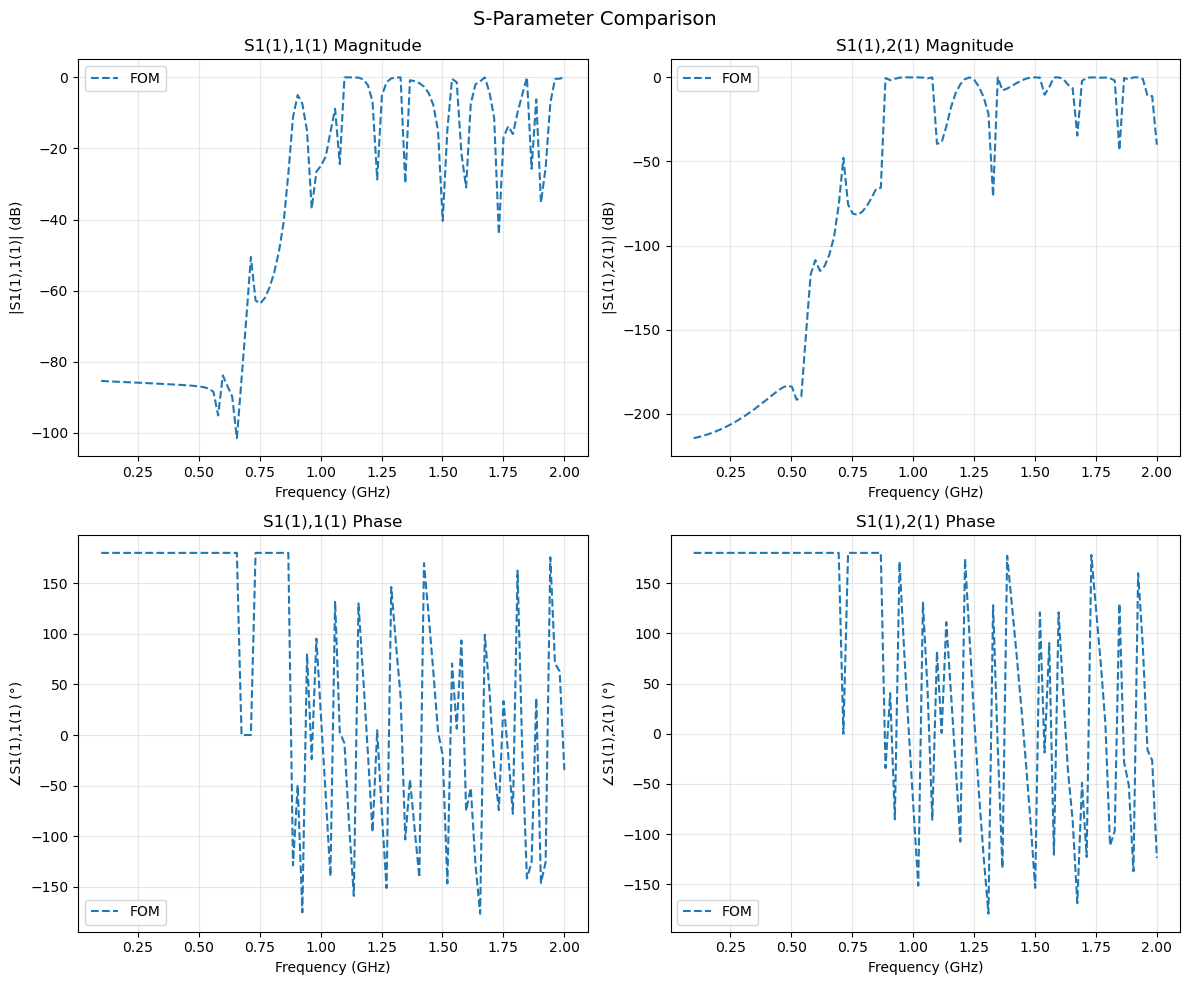

(<Figure size 1200x1000 with 4 Axes>,
 {'S1(1),1(1)_mag': <Axes: title={'center': 'S1(1),1(1) Magnitude'}, xlabel='Frequency (GHz)', ylabel='|S1(1),1(1)| (dB)'>,
  'S1(1),1(1)_phase': <Axes: title={'center': 'S1(1),1(1) Phase'}, xlabel='Frequency (GHz)', ylabel='∠S1(1),1(1) (°)'>,
  'S1(1),2(1)_mag': <Axes: title={'center': 'S1(1),2(1) Magnitude'}, xlabel='Frequency (GHz)', ylabel='|S1(1),2(1)| (dB)'>,
  'S1(1),2(1)_phase': <Axes: title={'center': 'S1(1),2(1) Phase'}, xlabel='Frequency (GHz)', ylabel='∠S1(1),2(1) (°)'>})

In [4]:
# 3. FOM solve
fds = FrequencyDomainSolver(geo, order=3)
%time fds.assemble_matrices(nportmodes=3)
%time fds.solve(0.1, 2, 100, store_snapshots=True, solver_type='direct')

# 4. Quick comparison plots - just pass the objects!
frequencies = np.linspace(0.1, 2, 1000) * 1e9
plot_z_comparison([fds], frequencies=frequencies)
plot_s_comparison([fds], frequencies=frequencies)

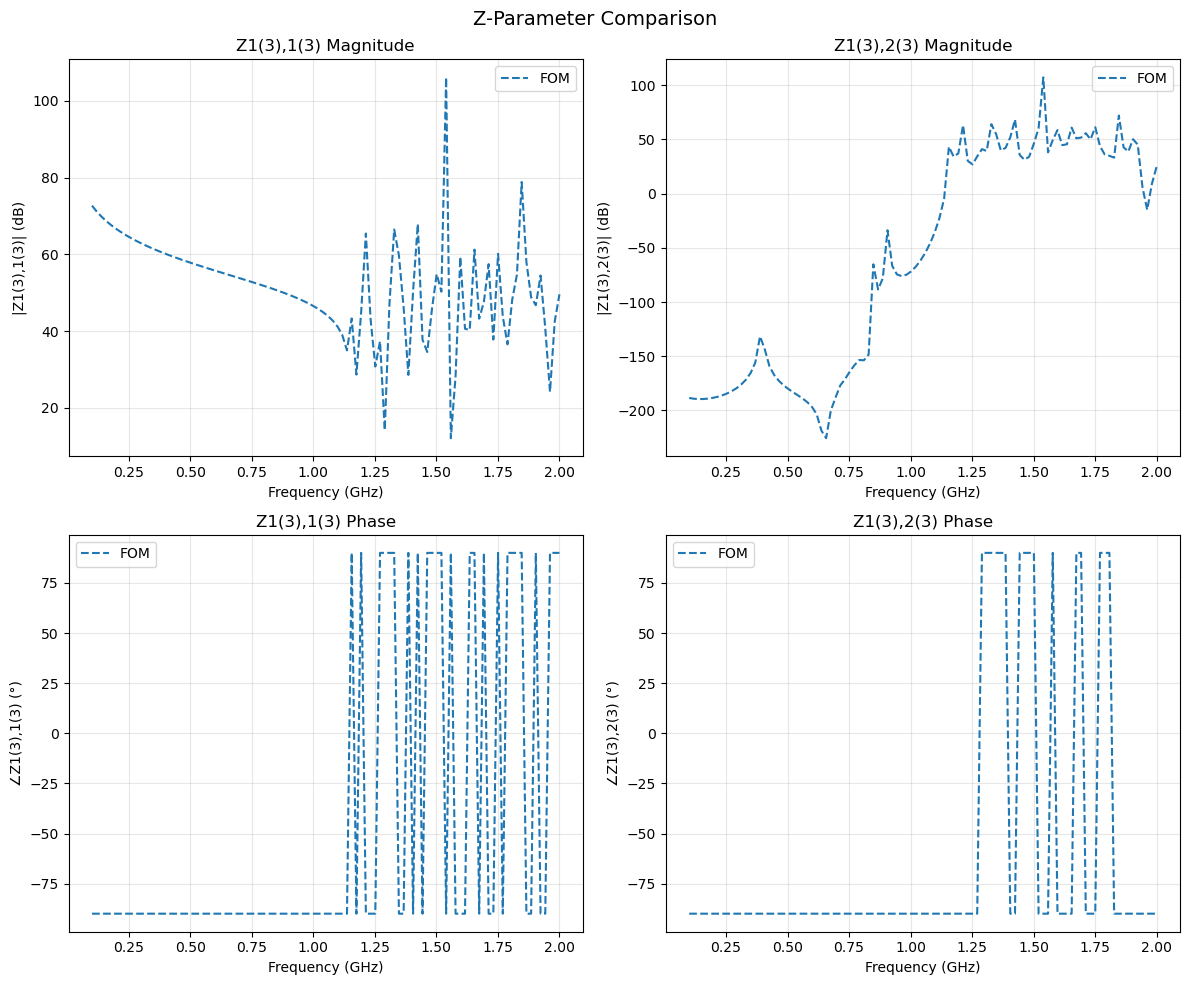

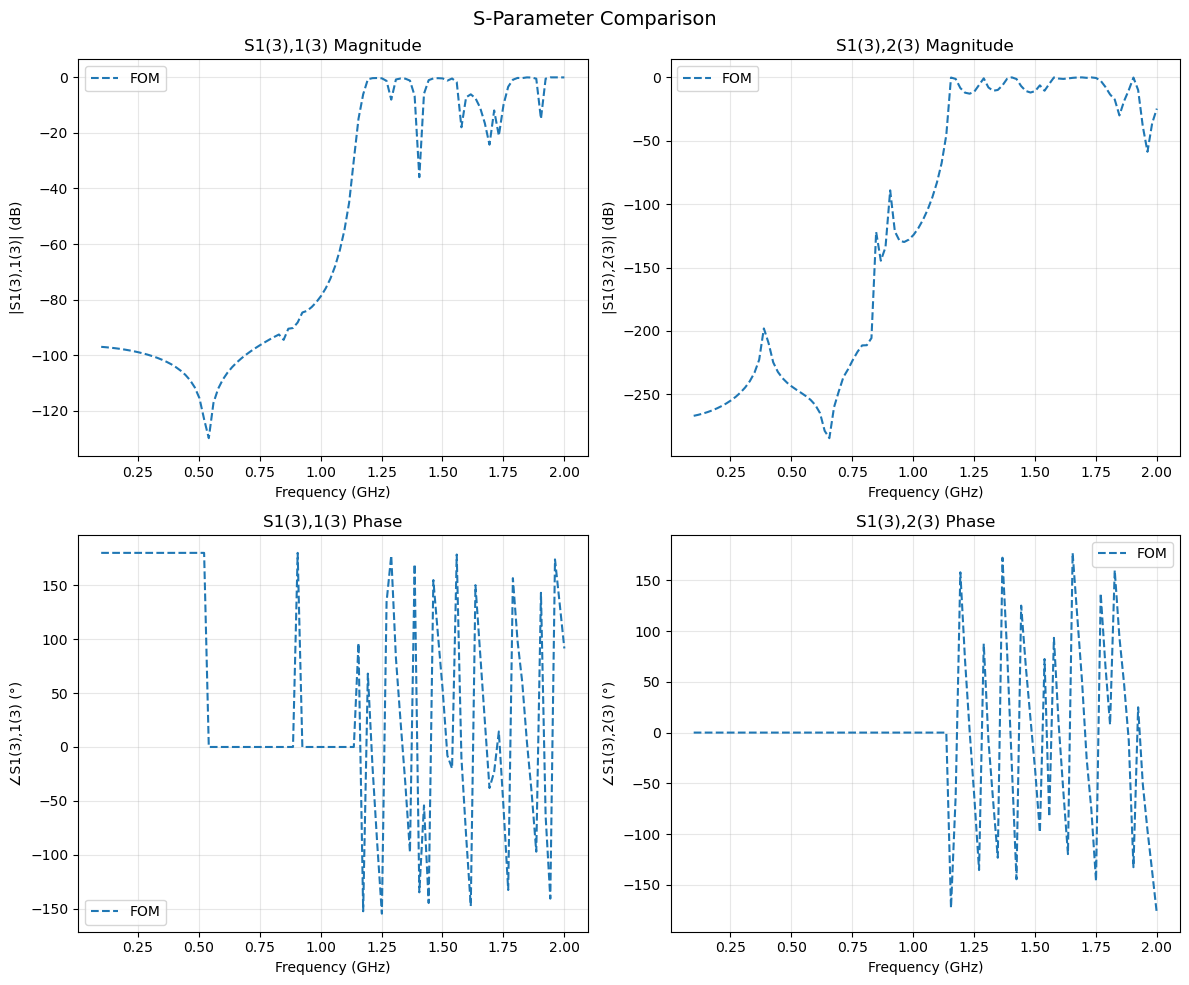

(<Figure size 1200x1000 with 4 Axes>,
 {'S1(3),1(3)_mag': <Axes: title={'center': 'S1(3),1(3) Magnitude'}, xlabel='Frequency (GHz)', ylabel='|S1(3),1(3)| (dB)'>,
  'S1(3),1(3)_phase': <Axes: title={'center': 'S1(3),1(3) Phase'}, xlabel='Frequency (GHz)', ylabel='∠S1(3),1(3) (°)'>,
  'S1(3),2(3)_mag': <Axes: title={'center': 'S1(3),2(3) Magnitude'}, xlabel='Frequency (GHz)', ylabel='|S1(3),2(3)| (dB)'>,
  'S1(3),2(3)_phase': <Axes: title={'center': 'S1(3),2(3) Phase'}, xlabel='Frequency (GHz)', ylabel='∠S1(3),2(3) (°)'>})

In [5]:
plot_z_comparison([fds], frequencies=frequencies, mode_pairs=[(3, 3), (3, 3)])
plot_s_comparison([fds], frequencies=frequencies, mode_pairs=[(3, 3), (3, 3)])

In [6]:
# # Solve with concatenation method
# fds = FrequencyDomainSolver(geo, order=3)
# fds.assemble_matrices(nportmodes=1)

# # Option 1: Use concatenate directly
# results = fds.solve(0.1, 3, 100, 
#                     per_domain=True, 
#                     global_method='concatenate')

# # Option 2: Compare all methods
# comparison = fds.compare_methods(0.1, 3, 100, 
#                                   methods=['coupled', 'cascade', 'concatenate'])

# # The concatenate method should match coupled exactly (within numerical precision)
# # while cascade may show errors if there are significant inter-domain reflections

In [7]:
# After ROM is working...
from rom.reduction import ModelOrderReduction

rom = ModelOrderReduction(fds)
%time rom.reduce(max_rank=1000, tol=1e-6)
%time rom.solve(0.1, 2, 1000)




Model Order Reduction

Domain: cell_1
  Full DOFs: 33852
  Snapshots: 600
  Reduced DOFs: 210
  Compression: 99.4%
  Singular value decay: 2.33e+06 → 1.56e+00

Domain: cell_2
  Full DOFs: 32225
  Snapshots: 600
  Reduced DOFs: 206
  Compression: 99.4%
  Singular value decay: 5.94e+06 → 4.94e+00

------------------------------------------------------------
Total: 66077 → 416 DOFs
Overall compression: 99.4%
CPU times: total: 37.2 s
Wall time: 9.78 s

Coupled system: 416 -> 413 DOFs
External port-modes: 6, Internal port-modes: 6
Port connections: 1 (× 3 modes each)
CPU times: total: 1h 11min
Wall time: 17min 9s


{'frequencies': array([1.00000000e+08, 1.01901902e+08, 1.03803804e+08, 1.05705706e+08,
        1.07607608e+08, 1.09509510e+08, 1.11411411e+08, 1.13313313e+08,
        1.15215215e+08, 1.17117117e+08, 1.19019019e+08, 1.20920921e+08,
        1.22822823e+08, 1.24724725e+08, 1.26626627e+08, 1.28528529e+08,
        1.30430430e+08, 1.32332332e+08, 1.34234234e+08, 1.36136136e+08,
        1.38038038e+08, 1.39939940e+08, 1.41841842e+08, 1.43743744e+08,
        1.45645646e+08, 1.47547548e+08, 1.49449449e+08, 1.51351351e+08,
        1.53253253e+08, 1.55155155e+08, 1.57057057e+08, 1.58958959e+08,
        1.60860861e+08, 1.62762763e+08, 1.64664665e+08, 1.66566567e+08,
        1.68468468e+08, 1.70370370e+08, 1.72272272e+08, 1.74174174e+08,
        1.76076076e+08, 1.77977978e+08, 1.79879880e+08, 1.81781782e+08,
        1.83683684e+08, 1.85585586e+08, 1.87487487e+08, 1.89389389e+08,
        1.91291291e+08, 1.93193193e+08, 1.95095095e+08, 1.96996997e+08,
        1.98898899e+08, 2.00800801e+08, 2.0270270

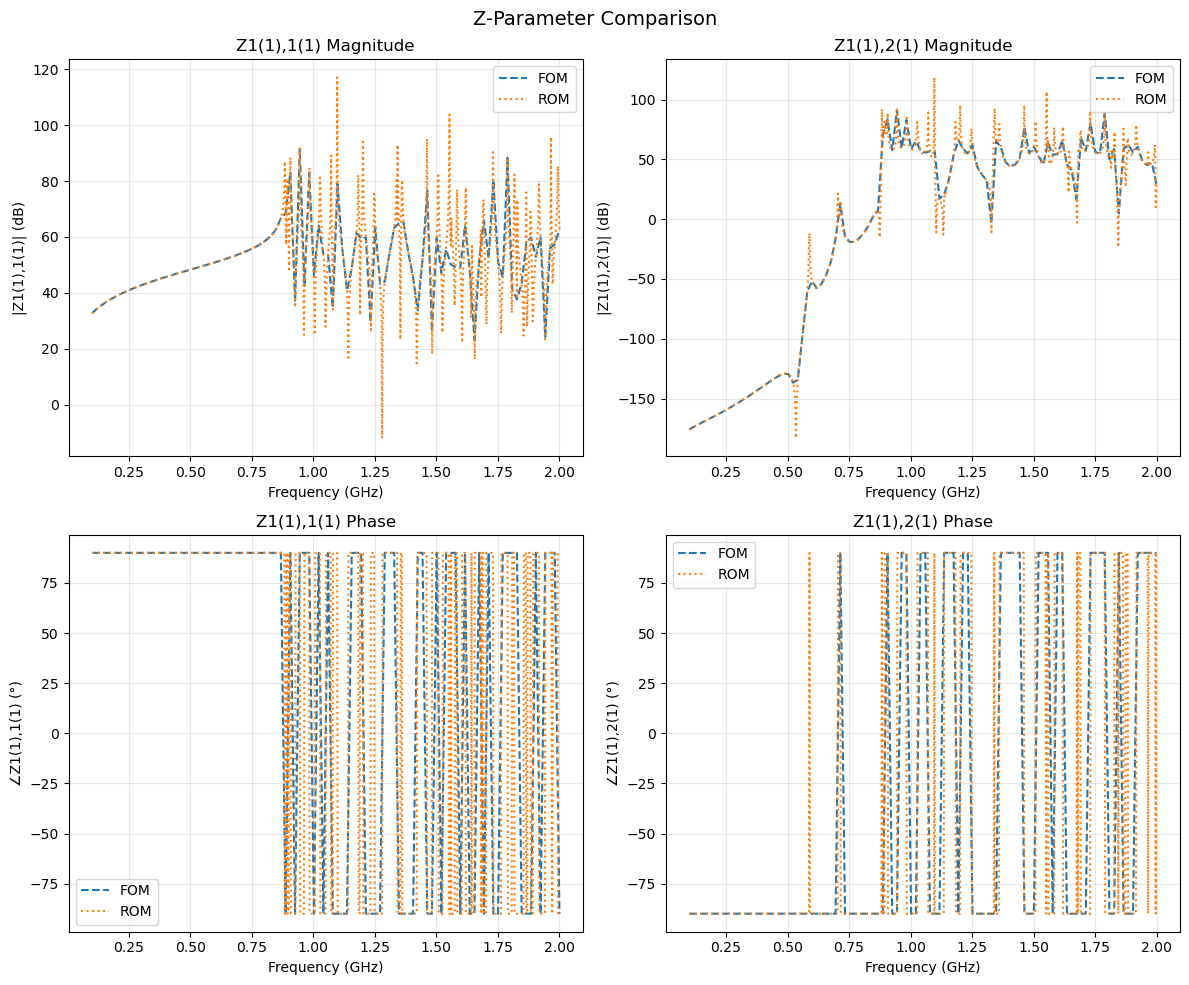

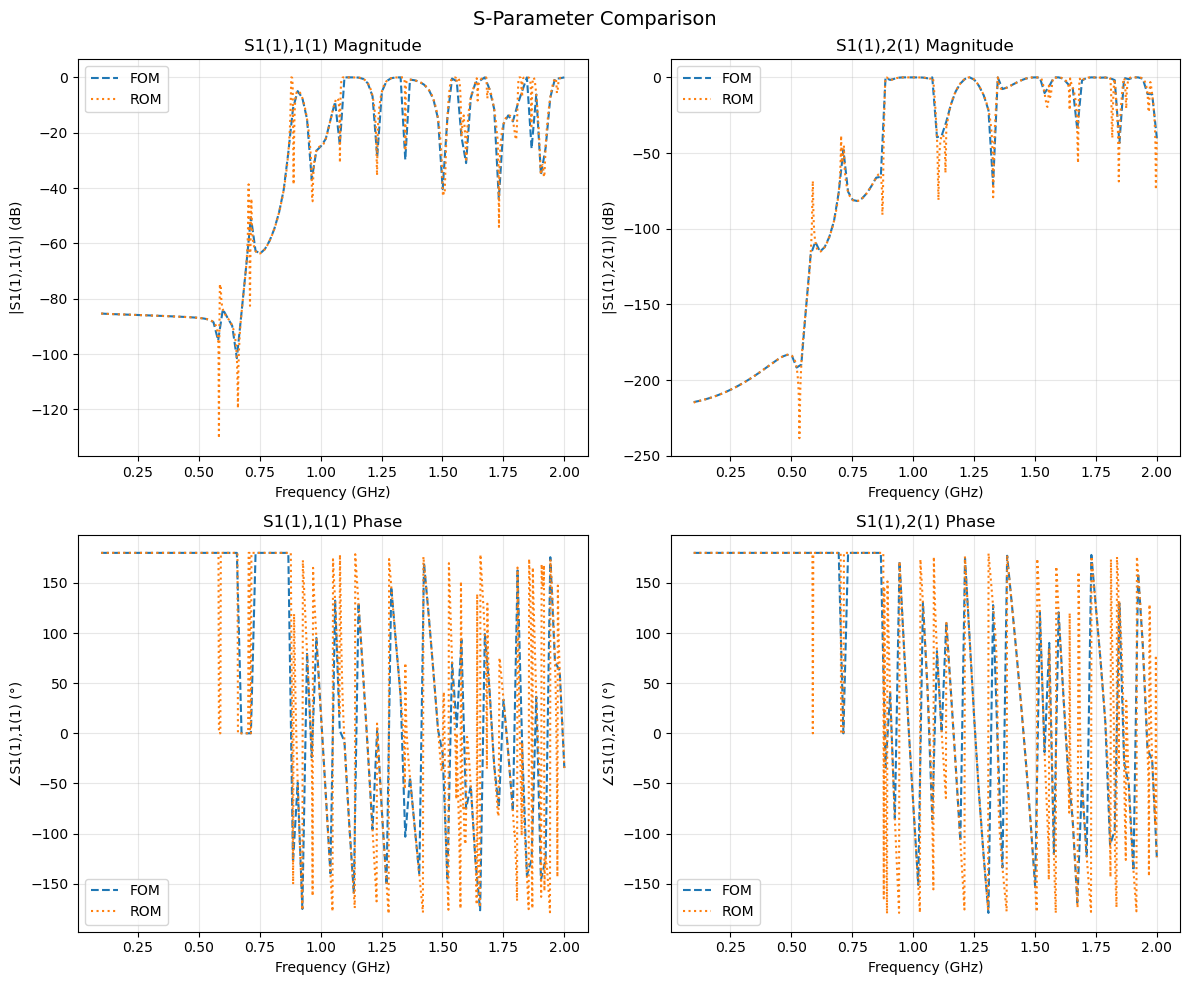

(<Figure size 1200x1000 with 4 Axes>,
 {'S1(1),1(1)_mag': <Axes: title={'center': 'S1(1),1(1) Magnitude'}, xlabel='Frequency (GHz)', ylabel='|S1(1),1(1)| (dB)'>,
  'S1(1),1(1)_phase': <Axes: title={'center': 'S1(1),1(1) Phase'}, xlabel='Frequency (GHz)', ylabel='∠S1(1),1(1) (°)'>,
  'S1(1),2(1)_mag': <Axes: title={'center': 'S1(1),2(1) Magnitude'}, xlabel='Frequency (GHz)', ylabel='|S1(1),2(1)| (dB)'>,
  'S1(1),2(1)_phase': <Axes: title={'center': 'S1(1),2(1) Phase'}, xlabel='Frequency (GHz)', ylabel='∠S1(1),2(1) (°)'>})

In [8]:

# Compare all three
plot_z_comparison([fds, rom], frequencies=frequencies,
                  labels=['FOM', 'ROM'])
plot_s_comparison([fds, rom], frequencies=frequencies,
                  labels=['FOM', 'ROM'])

## New Result-Object API

The new API provides a navigable object graph:
- `fds.fom` — global FOM result
- `fds.fom.rom` — ROM of the global FOM
- `fds.foms` — per-domain FOMs (multi-solid only)
- `fds.foms.roms.concat.rom` — full ROM concatenation chain

Each result object has `.plot_s()`, `.plot_z()`, `.plot_eigenvalues()` methods.

Global FOM: FOMResult(domain='global', n_ports=2, n_freq=100)
Per-domain FOMs: FOMCollection([cell_1, cell_2])
  Domain 0: FOMResult(domain='cell_1', n_ports=2, n_freq=100)
  Domain 1: FOMResult(domain='cell_2', n_ports=2, n_freq=100)


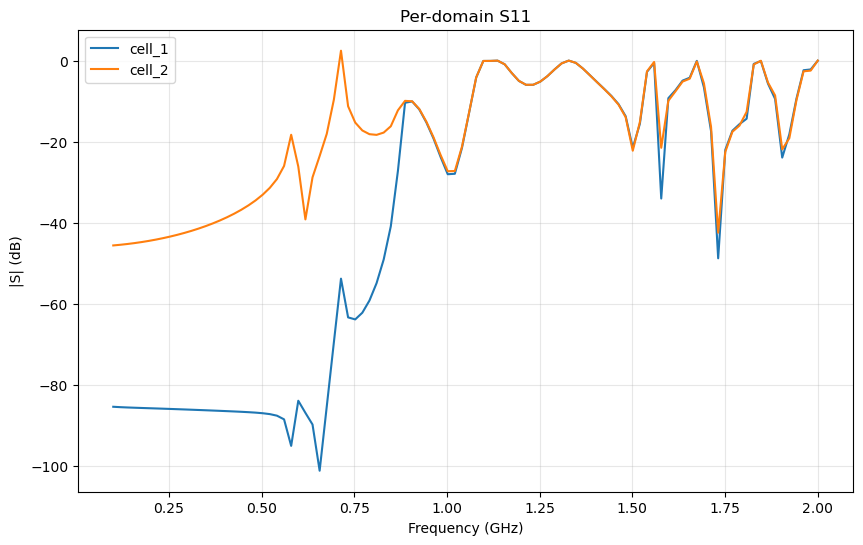


Model Order Reduction

Domain: cell_1
  Full DOFs: 33852
  Snapshots: 600
  Reduced DOFs: 210
  Compression: 99.4%
  Singular value decay: 2.33e+06 → 1.56e+00

Domain: cell_2
  Full DOFs: 32225
  Snapshots: 600
  Reduced DOFs: 206
  Compression: 99.4%
  Singular value decay: 5.94e+06 → 4.94e+00

------------------------------------------------------------
Total: 66077 → 416 DOFs
Overall compression: 99.4%

Coupled system: 416 -> 413 DOFs
External port-modes: 6, Internal port-modes: 6
Port connections: 1 (× 3 modes each)

Reduced concatenated system: 413 -> 371 DOFs
Compression: 10.2%
Concatenated ROM: ROMResult(domain='concat_rom', n_ports=6, n_freq=100)


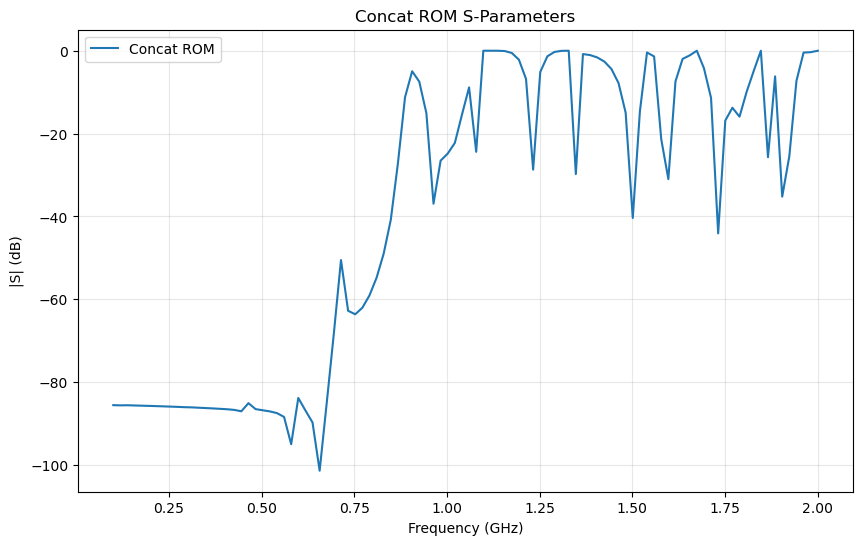

In [9]:
# === New API: multi-solid result-object navigation ===

# Global FOM (coupled solve over entire mesh)
print("Global FOM:", fds.fom)

# Per-domain FOMs
print("Per-domain FOMs:", fds.foms)
for i, fom_i in enumerate(fds.foms):
    print(f"  Domain {i}: {fom_i}")

# Plot per-domain S-parameters overlaid
fig, ax = fds.foms.plot_s(params=['1(1)1(1)'], title='Per-domain S11')
plt.show()

# Full chain: per-domain → ROM each → concatenate → further reduce
# This is the 1→2→3→4→5 path from the architecture diagram
concat_rom = fds.foms.roms.concat.rom
print("Concatenated ROM:", concat_rom)
fig, ax = concat_rom.plot_s(params=['1(1)1(1)'], label='Concat ROM')
plt.show()

Concat result: ConcatResult(n_ports=6, n_freq=100)
N ports: 6
Ports: ['port1(1)', 'port1(2)', 'port1(3)', 'port2(1)', 'port2(2)', 'port2(3)']


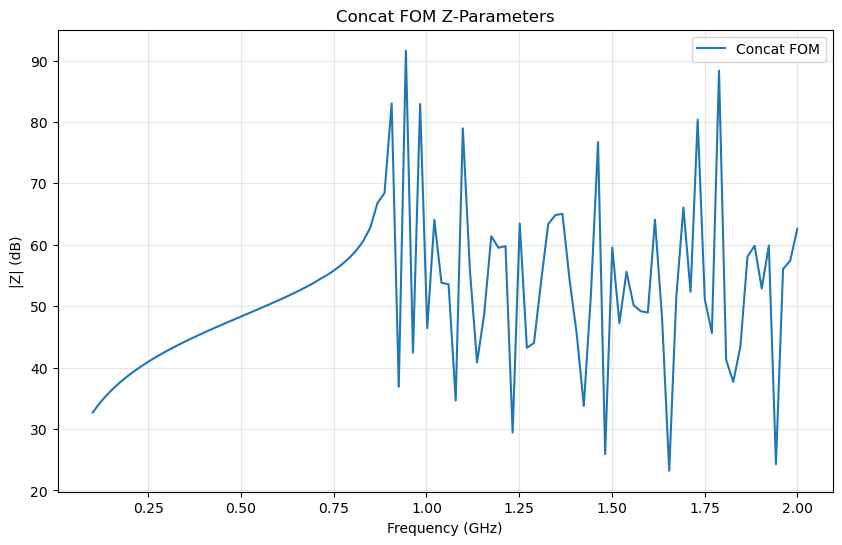

In [10]:
# === Concatenation info (new API) ===
concat_result = fds.foms.roms.concat
print(f"Concat result: {concat_result}")
print(f"N ports: {concat_result.n_ports}")
print(f"Ports: {concat_result.ports}")
fig, ax = concat_result.plot_z(params=['1(1)1(1)'], label='Concat FOM')
plt.show()


In [ ]:
fds.foms.roms.concat